# Pricer with RoBerta


In [1]:
# pip installs

!pip install -q datasets requests torch transformers accelerate sentencepiece wandb matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pathos 0.3.3 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
pathos 0.3.3 requires multiprocess>=0.70.17, but you have multiprocess 0.70.16 which is incompatible.


In [72]:
# imports
# With much thanks to Islam S. for identifying that there was a missing import!

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import transformers
import wandb
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, set_seed
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

In [146]:
# Constants

BASE_MODEL = "roberta-base" # "roberta-large"
PROJECT_NAME = "pricer-roberta"
HF_USER = "flacout" # your HF name here!

# Data

DATASET_NAME = f"{HF_USER}/pricer-data"

# Run name for saving the model in the hub

RUN_NAME =  f"{datetime.now():%Y-%m-%d_%H.%M.%S}"
PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
HUB_MODEL_NAME = f"{HF_USER}/{PROJECT_RUN_NAME}"


# Hyperparameters for Training

EPOCHS = 5000 # you can do more epochs if you wish, but only 1 is needed - more is probably overkill
BATCH_SIZE = 2 # on an A100 box this can go up to 16
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 1e-3
LR_SCHEDULER_TYPE = 'cosine'  # avoid getting stuck in a local minima
WARMUP_RATIO = 0.03     # at the begining of training start with lower LR.
OPTIMIZER = 'adamw_torch'

# Admin config - note that SAVE_STEPS is how often it will upload to the hub
# I've changed this from 5000 to 2000 so that you get more frequent saves

STEPS = 50
SAVE_STEPS = 2000
LOG_TO_WANDB = True   # weight and bias

%matplotlib inline

# Used for writing to output in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

In [113]:
HUB_MODEL_NAME

'flacout/pricer-roberta-2025-04-17_12.23.33'

In [75]:
# Log in to HuggingFace

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


In [76]:
# Log in to Weights & Biases
wandb_api_key = userdata.get('WANDB_API_KEY')
os.environ["WANDB_API_KEY"] = wandb_api_key
wandb.login()

# Configure Weights & Biases to record against our project
os.environ["WANDB_PROJECT"] = PROJECT_NAME
os.environ["WANDB_LOG_MODEL"] = "checkpoint" if LOG_TO_WANDB else "end"
os.environ["WANDB_WATCH"] = "gradients"

if LOG_TO_WANDB:
  wandb.init(project=PROJECT_NAME, name=RUN_NAME)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇███
train/grad_norm,▄▃▆▃█▆▆█▄▆▂▃▁▆▃▃▆▃▄▁▁▃▅▁▃▁▃▁▂▃▂▂▁▃▃▄▂▄▅▂
train/learning_rate,██████████▇▇▇▇▇▆▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
train/loss,█▆▅▆▅▄▅▅▄▃▃▃▂▃▃▂▂▁▁▂▁▂▂▂▃▁▁▂▂▂▁▂▂▂▂▂▂▁▁▂
total_flos,1.052434771968e+16
train/epoch,20
train/global_step,5000
train/grad_norm,1774.51111
train/learning_rate,0.0
train/loss,28884.2675


wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


## Load Dataset into correct format & Tokenize.

### Add label column and remove unecessary text

In [77]:
data_train = {
    "text": ["this item is very expensive", "this item is cheap and broken"],
    "label": [110.2, 5.2]
}

data_test = {
    "text": ["this item is luxurious", "this item doesn't work"],
    "label": [100.3, 2]
}

train = Dataset.from_dict(data_train)
test = Dataset.from_dict(data_test)

In [60]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
test = dataset['test']

# the price should be renamed as "label"
train = train.rename_column('price', 'label')
test = test.rename_column('price', 'label')


def remove_price_and_question(item):
    item['text'] = item['text'].split("\n\nPrice is $")[0]
    item['text'] = item['text'].split("How much does this cost to the nearest dollar?\n\n")[1]
    return item

train = train.map(remove_price_and_question)
test = test.map(remove_price_and_question)

In [61]:
train = train.select(range(2000))
test = test.select(range(2000))

### Categorize labels (if using the categorical prediction)

In [62]:
'''def cat_prices(item):
    item['labels'] = int(item['label']//10)
    return item

train = train.map(cat_prices)
test = test.map(cat_prices)

train = train.remove_columns(['label'])
test = test.remove_columns(['label'])'''

"def cat_prices(item):\n    item['labels'] = int(item['label']//10)\n    return item\n\ntrain = train.map(cat_prices)\ntest = test.map(cat_prices)\n\ntrain = train.remove_columns(['label'])\ntest = test.remove_columns(['label'])"

In [63]:
test[0]

{'text': "OEM AC Compressor w/A/C Repair Kit For Ford F150 F-150 V8 & Lincoln Mark LT 2007 2008 - BuyAutoParts NEW\nAs one of the world's largest automotive parts suppliers, our parts are trusted every day by mechanics and vehicle owners worldwide. This A/C Compressor and Components Kit is manufactured and tested to the strictest OE standards for unparalleled performance. Built for trouble-free ownership and 100% visually inspected and quality tested, this A/C Compressor and Components Kit is backed by our 100% satisfaction guarantee. Guaranteed Exact Fit for easy installation 100% BRAND NEW, premium ISO/TS 16949 quality - tested to meet or exceed OEM specifications Engineered for superior durability, backed by industry-leading unlimited-mileage warranty Included in this K",
 'label': 374.41}

### Tokenize

In [79]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)

In [80]:
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True)

tokenized_train = train.map(tokenize)
tokenized_test = test.map(tokenize)

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

## Load model and train

In [147]:
# Setting num_labels=1 switches the model to regression mode.
# The final head is a linear layer outputting a single value.

base_model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=1, problem_type="regression")
#base_model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=100)

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e6:.1f} MB")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Memory footprint: 498.6 MB


In [148]:
for param in base_model.roberta.parameters():
    param.requires_grad = False
    
trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in base_model.parameters())
print(f"Trainable parameters: {trainable_params} / {total_params}")

Trainable parameters: 591361 / 124646401


In [149]:
base_model

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [150]:
base_model.config

RobertaConfig {
  "_attn_implementation_autoset": true,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "problem_type": "regression",
  "torch_dtype": "float32",
  "transformers_version": "4.51.3",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}

In [151]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.squeeze()
    return {"mse": mean_squared_error(labels, predictions)}

training_args = TrainingArguments(
    output_dir=PROJECT_RUN_NAME,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="no",
    optim=OPTIMIZER,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    #fp16=True,
    max_grad_norm=0.3,
    max_steps=-1,
    #warmup_ratio=WARMUP_RATIO,
    group_by_length=True,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    report_to="wandb" if LOG_TO_WANDB else None,
    run_name=RUN_NAME,
    save_total_limit=10,
    logging_steps=STEPS,
    save_steps=SAVE_STEPS,
    save_strategy="steps",
    hub_strategy="every_save",
    push_to_hub=False,
    hub_model_id=HUB_MODEL_NAME,
    hub_private_repo=True
)

trainer = Trainer(
    model=base_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


/tmp/ipykernel_26425/1376655002.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [152]:
trainer.train()

Step,Training Loss
50,4490.795300
100,2824.857500
150,2762.136600
200,2655.880900
250,2251.473600
300,1774.907500
350,1214.775400
400,765.854300
450,547.910000
500,496.290500


wandb: Adding directory to artifact (./pricer-roberta-2025-04-17_12.30.51/checkpoint-2000)... Done. 1.1s
wandb: Adding directory to artifact (./pricer-roberta-2025-04-17_12.30.51/checkpoint-4000)... Done. 1.1s
wandb: Adding directory to artifact (./pricer-roberta-2025-04-17_12.30.51/checkpoint-5000)... Done. 1.1s


TrainOutput(global_step=5000, training_loss=410.8418428710938, metrics={'train_runtime': 120.0666, 'train_samples_per_second': 83.287, 'train_steps_per_second': 41.644, 'total_flos': 2631086929920000.0, 'train_loss': 410.8418428710938, 'epoch': 5000.0})

In [39]:
if LOG_TO_WANDB:
  wandb.finish()

train/epoch,▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/grad_norm,▄▂▁▄▇▆▅▃▅▃▆▅▅▄▅▃▂▅▅▄▄▃▅▄▃▄▅▄▂▆▃▂▃▂▆█▄▇▅▅
train/learning_rate,▆█████████▇▇▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
train/loss,█▇▄▄▃▄▂▂▃▃▂▂▂▂▂▂▂▂▃▂▂▂▂▂▁▁▂▂▂▂▂▂▁▁▂▂▁▁▂▁
total_flos,1.053370269696e+16
train/epoch,20
train/global_step,5000
train/grad_norm,5.22061
train/learning_rate,0.0
train/loss,3.9402


## Prediction & Results

In [153]:
def model_predict(prompt):
    set_seed(42)
    inputs = tokenizer(prompt, return_tensors="pt", padding="max_length", truncation=True, max_length=512).to('cuda')
    with torch.no_grad():
        prediction = base_model(**inputs).logits.squeeze().item()
    return prediction

In [155]:
index = 1
print("label", train[index]['label'])
print("prediction", model_predict(train[index]['text']))

label 5.2
prediction 18.255098342895508


# Analyse prediction

In [169]:
base_model.config.output_hidden_states = True

In [170]:
inputs = tokenizer(train[1]['text'], return_tensors="pt", padding="max_length", truncation=True, max_length=512).to('cuda')
print(inputs)
with torch.no_grad():
    logits = base_model(**inputs).logits
    print("logit", logits)

{'input_ids': tensor([[   0, 9226, 6880,   16, 6162,    8, 3187,    2,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,

In [171]:
inputs = tokenizer(train[0]['text'], return_tensors="pt", padding="max_length", truncation=True, max_length=512).to('cuda')
print(inputs)
with torch.no_grad():
    logits = base_model(**inputs).logits
    print("logit", logits)

{'input_ids': tensor([[   0, 9226, 6880,   16,  182, 3214,    2,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,

In [178]:
inputs = tokenizer(train[0]['text'], return_tensors="pt", padding="max_length", truncation=True, max_length=512).to('cuda')
print(inputs)
with torch.no_grad():
    outputs = base_model(**inputs)
    hidden_states = outputs.hidden_states  # 13 layers output
    layer_num = 12
    encoder_output = hidden_states[layer_num] # [batch_size, seq_length, encoding]
    print(encoder_output.shape)

{'input_ids': tensor([[   0, 9226, 6880,   16,  182, 3214,    2,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,

In [26]:
class Tester:

    def __init__(self, predictor, data, title=None, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = max(self.predictor(datapoint["text"]), 0)
        truth = datapoint["label"]
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint["text"][:20] + "..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

1: Guess: $214.04 Truth: $374.41 Error: $160.37 SLE: 0.31 Item: OEM AC Compressor w/...
2: Guess: $214.04 Truth: $225.11 Error: $11.07 SLE: 0.00 Item: Motorcraft YB3125 Fa...
3: Guess: $214.04 Truth: $61.68 Error: $152.36 SLE: 1.52 Item: Dorman Front Washer ...
4: Guess: $214.04 Truth: $599.99 Error: $385.95 SLE: 1.06 Item: HP Premium HD Plus T...
5: Guess: $214.04 Truth: $16.99 Error: $197.05 SLE: 6.16 Item: Super Switch Pickup ...
6: Guess: $214.04 Truth: $31.99 Error: $182.05 SLE: 3.51 Item: Horror Bookmarks, Re...
7: Guess: $214.04 Truth: $101.79 Error: $112.25 SLE: 0.54 Item: SK6241 - Stinger 4 G...
8: Guess: $214.04 Truth: $289.00 Error: $74.96 SLE: 0.09 Item: Godox ML60Bi LED Lig...
9: Guess: $214.04 Truth: $635.86 Error: $421.82 SLE: 1.18 Item: Randall G3 Plus Comb...
10: Guess: $214.04 Truth: $65.99 Error: $148.05 SLE: 1.36 Item: HOLDWILL 6 Pack LED ...
11: Guess: $214.04 Truth: $254.21 Error: $40.17 SLE: 0.03 Item: Viking Horns 3 Gallo...
12: Guess: $214.04 Truth: $412.99 Err

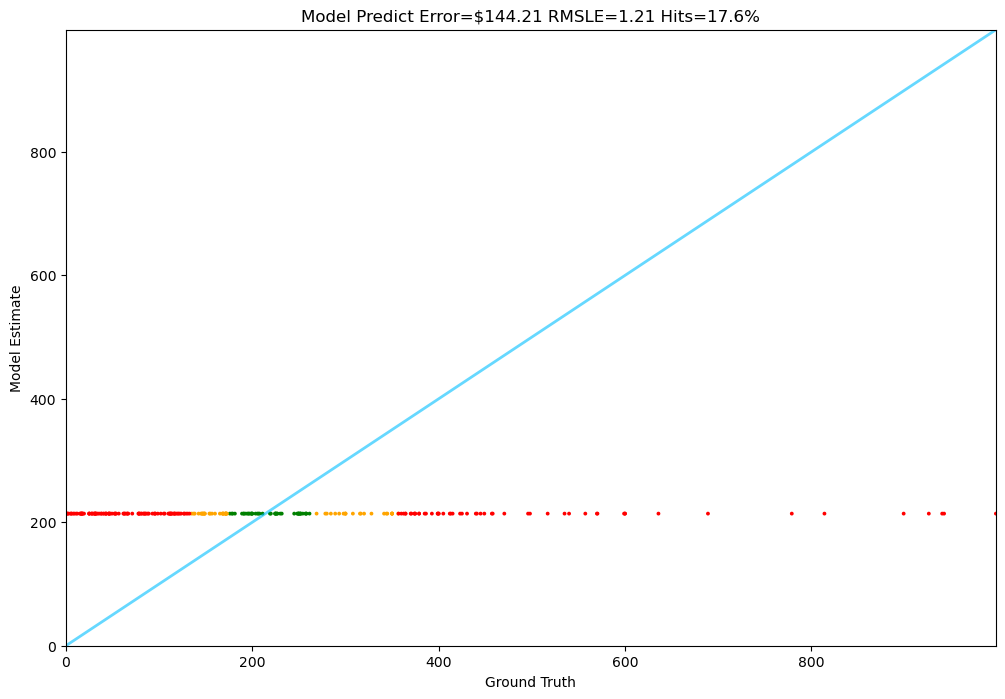

In [27]:
Tester.test(model_predict, test)